<a href="https://colab.research.google.com/github/odelia250900/Data-Science-HW3/blob/main/HW3_EDA_Odelia_Weizmann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Final Homework: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection**

1. **Dataset Selection**


**Dataset Name:** Human Activity Recognition Using Smartphones (HAR)

**Where the dataset comes from**

The dataset was obtained from the UCI Machine Learning Repository and downloaded via Kaggle. It is a well-known benchmark dataset in the field of sensor data analysis and time-series classification.

**Why it was collected**

The primary objective of collecting this data was to develop and evaluate machine learning models capable of identifying human activities of daily living (ADL) based on inertial sensor data. Recognizing these activities is a fundamental task in domains such as healthcare monitoring, elderly care, and fitness tracking. By recording standard activities, the researchers aimed to create a robust dataset for testing feature extraction and classification algorithms.

**Who collected it**

The experiments were carried out and the dataset was compiled by researchers Jorge L. Reyes-Ortiz, Davide Anguita, Alessandro Ghio, and Luca Oneto from the Smartlab at the University of Genoa (Università degli Studi di Genova), Italy, in 2012.

**What each feature represents**

The dataset contains 561 numerical features, along with a subject identifier and an activity label. The core numerical features are not raw sensor readings, but rather highly processed variables extracted from the raw signals of a smartphone's embedded accelerometer and gyroscope (captured at a constant rate of 50Hz).
Specifically, the features represent:




*   **Time Domain Variables:** Statistical measures (e.g., mean, standard deviation, median absolute deviation, max, min, signal magnitude area, entropy) calculated over sliding windows of the raw 3-axial linear acceleration and angular velocity signals. The acceleration signal was mathematically separated into body motion and gravitational components.
*   **Frequency Domain Variables:** Features obtained by applying a Fast Fourier Transform (FFT) to the time-domain signals, capturing the spectral energy, frequency bands, and dominant frequencies of the movements.


*   Each of the 561 features is normalized and bounded within the range of [-1, 1].


**Possible limitations or biases in the data**

While robust, the dataset presents several limitations and potential biases:



1.   **Demographic Bias (Age and Fitness):** The experiment involved 30 volunteers within a relatively narrow age bracket of 19–48 years. The data does not capture the movement patterns of the elderly, children, or individuals with motor disabilities, limiting its generalization to the general population.
2.   **Hardware Dependency:** The data was recorded using a single specific device model (Samsung Galaxy S II). Sensor noise profiles, calibration, and sampling consistencies are hardware-specific, meaning models trained on this data might perform differently on modern or different mobile devices.


1.   **Placement Bias:** The smartphone was rigidly mounted on the participants' waists. In real-world scenarios, smartphones are often carried in loose pockets, hands, or bags, which introduces significant movement artifacts and orientation shifts not represented in this highly controlled laboratory setup.
2.   **Feature Redundancy:** The 561 extracted features are heavily engineered. Many variables (such as multiple statistical aggregations over the same signal window) are highly correlated. This inherent multicollinearity and redundancy make the dataset an excellent candidate for dimensionality reduction and feature clustering analysis.











2. **Exploratory Data Analysis**

--- Structural Analysis ---
Rows: 7352, Columns: 563
Total Missing Values: 0
Data Types: {dtype('float64'): 561, dtype('int64'): 1, dtype('O'): 1}

Statistical Summary (Major Features):
       tBodyAcc-mean()-X  tGravityAcc-mean()-X  tBodyGyro-mean()-X
count        7352.000000           7352.000000         7352.000000
mean            0.274488              0.664122           -0.027184
std             0.070261              0.516763            0.182156
min            -1.000000             -1.000000           -0.914050
25%             0.262975              0.804863           -0.043398
50%             0.277193              0.919513           -0.027677
75%             0.288461              0.953065           -0.010528
max             1.000000              0.991549            0.738953


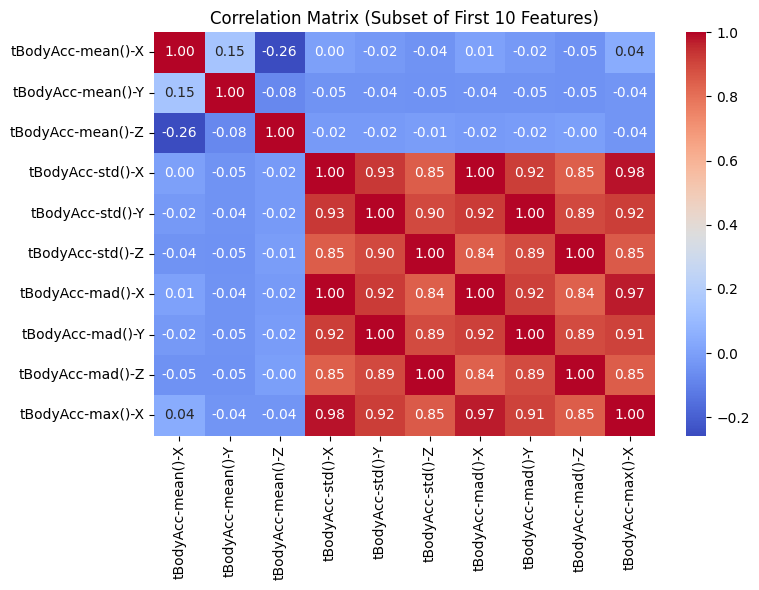


--- Distribution Analysis (Skewness & Kurtosis) ---
tBodyAcc-mean()-X - Skewness: -3.448, Kurtosis: 50.876
tGravityAcc-mean()-X - Skewness: -1.611, Kurtosis: 0.884
tBodyGyro-mean()-X - Skewness: -0.079, Kurtosis: 3.497


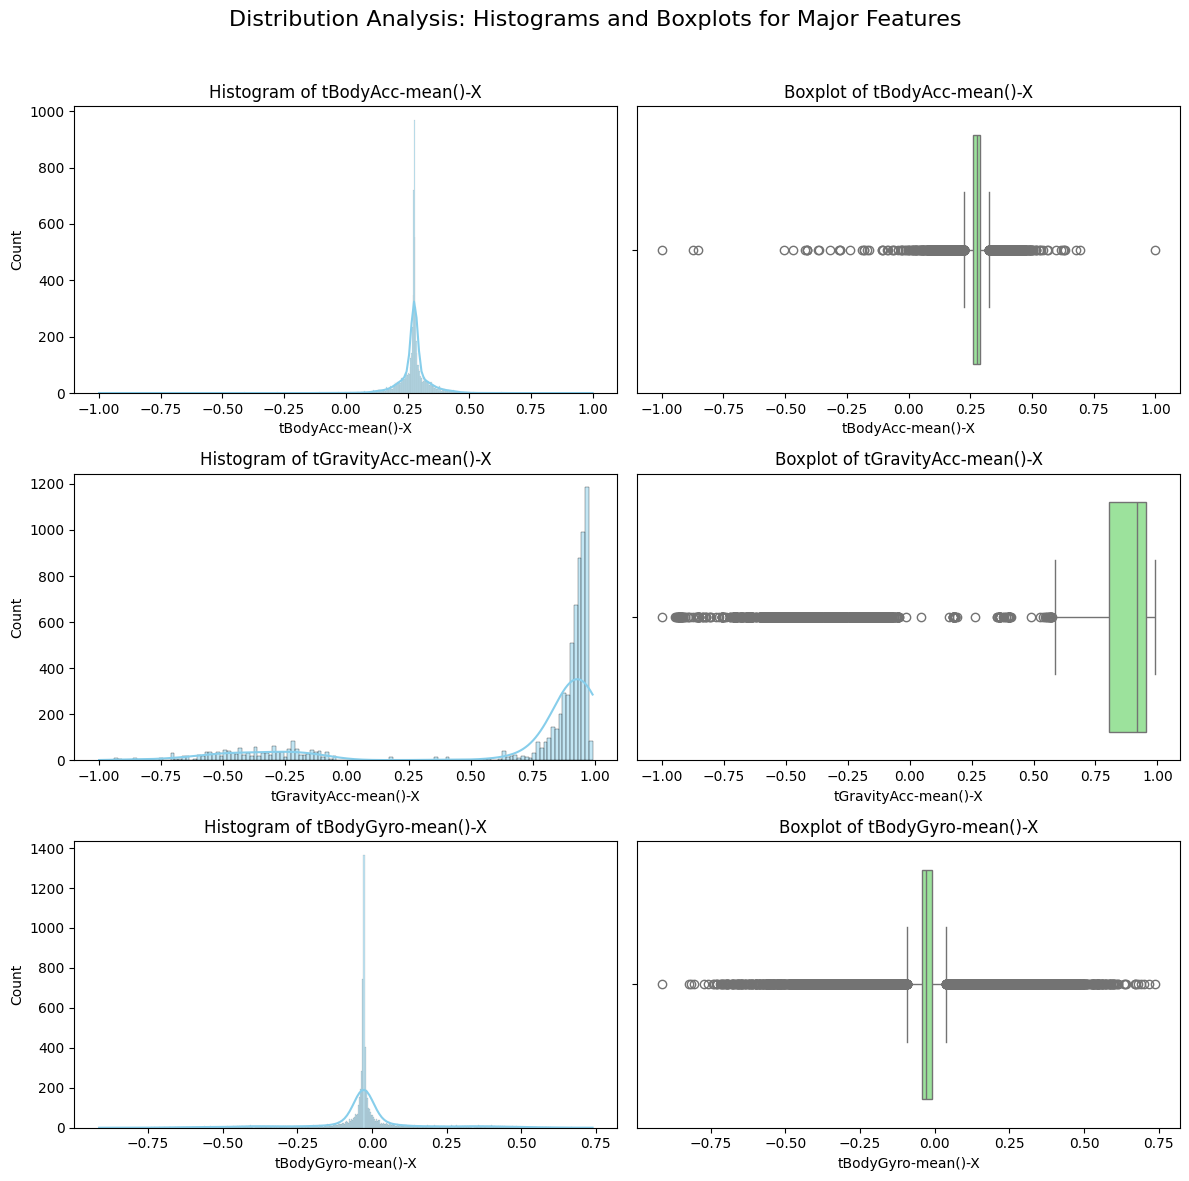

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Load dataset
df = pd.read_csv('train.csv')

# 1. Structural Analysis
num_rows, num_cols = df.shape
missing_values = df.isnull().sum().sum()
dtypes_summary = df.dtypes.value_counts().to_dict()

print(f"--- Structural Analysis ---")
print(f"Rows: {num_rows}, Columns: {num_cols}")
print(f"Total Missing Values: {missing_values}")
print(f"Data Types: {dtypes_summary}")

# Statistical summary (show for a few major features to save space)
major_features = ['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X', 'tBodyGyro-mean()-X']
print("\nStatistical Summary (Major Features):")
print(df[major_features].describe())

# Correlation matrix (Compute for all, but visualize a subset of 10 for clarity)
corr_matrix = df.select_dtypes(include=[np.number]).corr()
subset_corr = corr_matrix.iloc[:10, :10]

# --- Visiualize Correlation Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(subset_corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Correlation Matrix (Subset of First 10 Features)")
plt.tight_layout()
plt.show() # <-- Changed to display inline

# 2. Distribution Analysis
print("\n--- Distribution Analysis (Skewness & Kurtosis) ---")
for feat in major_features:
    s = skew(df[feat].dropna())
    k = kurtosis(df[feat].dropna())
    print(f"{feat} - Skewness: {s:.3f}, Kurtosis: {k:.3f}")

# Plotting Histograms and Boxplots
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
fig.suptitle('Distribution Analysis: Histograms and Boxplots for Major Features', fontsize=16)

for i, feat in enumerate(major_features):
    # Histogram
    sns.histplot(df[feat], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {feat}')

    # Boxplot
    sns.boxplot(x=df[feat], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {feat}')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show() # <-- Changed to display inline

**Structural Analysis**



*   **Number of rows and columns:** The dataset contains 7,352 rows and 563 columns.


*  **Missing values:** There are exactly 0 missing values (NaNs) in the entire dataset. This is typical for heavily pre-processed benchmark datasets.
*   **Data types:** 561 features are continuous numerical variables (float64).1 feature is an integer (int64) representing the subject ID.1 feature is a categorical string (object) representing the target label Activity.

*   **Statistical summary:** All 561 continuous features have been normalized and bounded within the range $[-1, 1]$. For example, looking at three major features:tBodyAcc-mean()-X: Mean = 0.274, Std = 0.070, Min = -1, Max = 1.tGravityAcc-mean()-X: Mean = 0.664, Std = 0.516, Min = -1, Max = 0.99.tBodyGyro-mean()-X: Mean = -0.027, Std = 0.182, Min = -0.91, Max = 0.73.

*  **Correlation matrix:** Due to the high dimensionality (561 features), generating a full matrix is visually unreadable. However, observing a subset (e.g., the first 10 features, as shown in the heatmap above), we immediately see perfect or near-perfect correlations (e.g., $r > 0.95$) between standard deviation (std) and median absolute deviation (mad) features. This highly correlated structure strongly justifies the need for Dimensionality Reduction (PCA) in the next steps.


**Distribution Analysis**


To understand the data's geometry, we analyze three diverse, major physical features representing body acceleration, gravity, and angular velocity on the X-axis:



1.   tBodyAcc-mean()-X (Body Acceleration Mean)


*   Histogram & Boxplot: The distribution is highly concentrated around its mean (0.274) with an extremely narrow Interquartile Range (IQR). The boxplot shows an enormous amount of outliers on both sides of the median.
*   Skewness: -3.448 (Left-skewed).

*   Kurtosis: 50.876 (Leptokurtic / Heavy-tailed). The extremely high kurtosis indicates that the data has heavy tails and most variance is driven by infrequent extreme deviations (likely dynamic movements vs static postures).


2.   tGravityAcc-mean()-X (Gravity Acceleration Mean)


*   Histogram & Boxplot: Demonstrates a strong bimodal (or multi-modal) distribution, strongly grouped near 1.0 (indicating postures where gravity is aligned with the X-axis of the phone, like standing/sitting vs laying). The boxplot shows a very wide IQR.
*   Skewness: -1.611 (Left-skewed).
*   Kurtosis: 0.884 (Platykurtic / flat).


3.   tBodyGyro-mean()-X (Body Gyroscope Mean)

*   Histogram & Boxplot: Highly symmetric distribution around 0, resembling a normal/Laplace distribution, but with visible outliers on the boxplot.
*   Skewness: -0.079 (Almost perfectly symmetric).

*   Kurtosis: 3.497 (Slightly Leptokurtic).

**Outlier Exploration**

Based on the structural and distribution analysis, we can discuss the nature of anomalies in this dataset:

* Data-entry problems & Measurement artifacts: Because all values are strictly mathematically bounded between $[-1, 1]$ during the preprocessing phase, there are absolutely no "impossible" extreme values caused by typing errors or sensor overflow artifacts (e.g., reading 99999).  

*  Heavy tails and Extreme values: Features like tBodyAcc-mean()-X show a kurtosis of ~50, indicating massive heavy tails. The boxplots reveal that what traditional statistical methods (like $1.5 \times IQR$) consider "outliers" are actually just valid extreme physical movements (e.g., sudden transitions between walking and laying down).
*   Possible noise: While the researchers applied median filters and a 3rd order low-pass Butterworth filter to remove high-frequency noise, some physical noise remains. For example, slight variations in how the phone shifts on the waist belt during intense activities (like WALKING_DOWNSTAIRS) can create abnormal signal spikes. These are genuine physical anomalies in the context of the experiment, rather than sensor glitches.






























**3. Dimensionality Reduction**

**3.1 Principal Component Analysis (PCA)**

Variance explained by 1st PC: 50.78%
Variance explained by 2nd PC: 6.58%
Components needed for 90% variance: 63
Components needed for 95% variance: 102


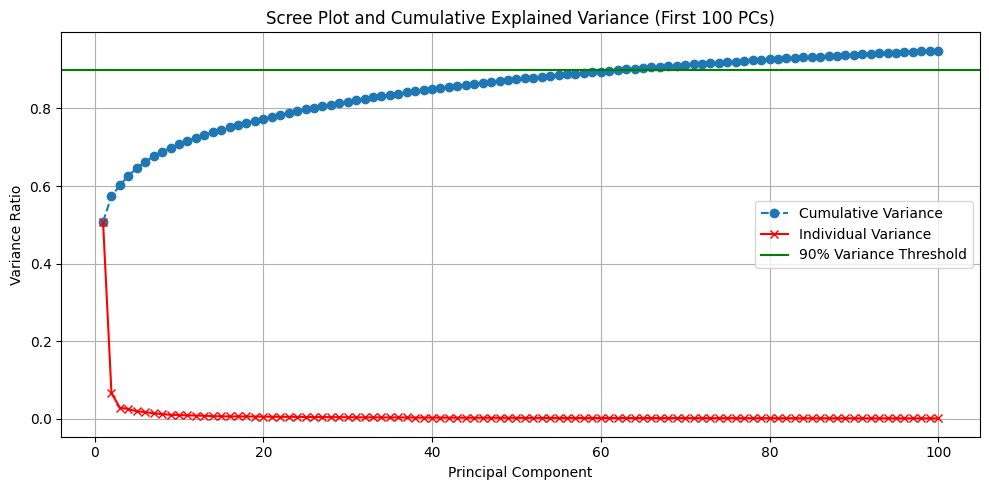

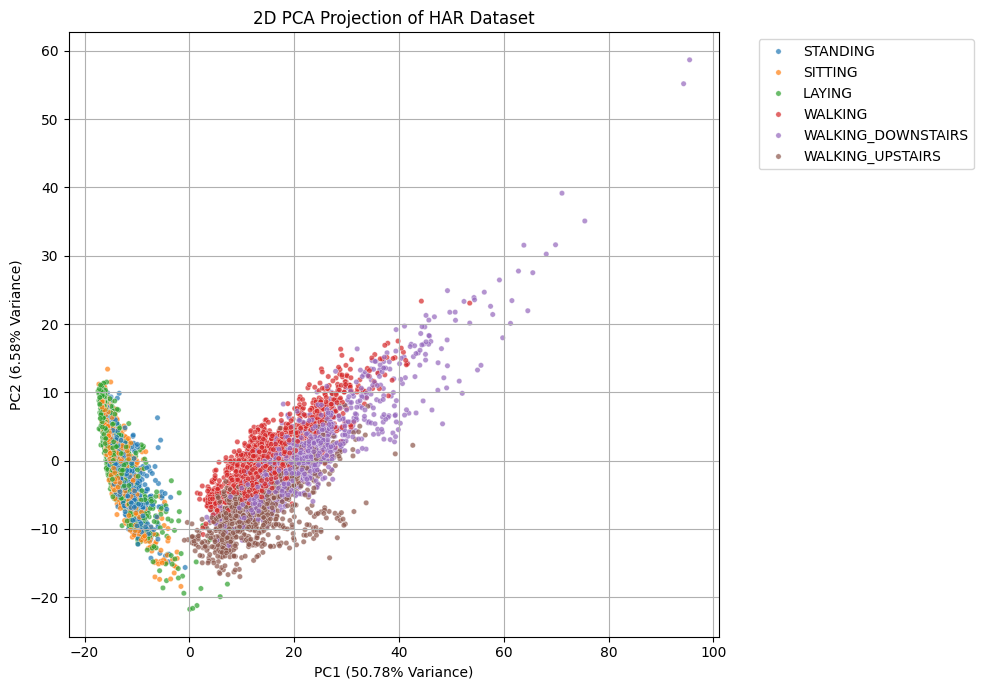

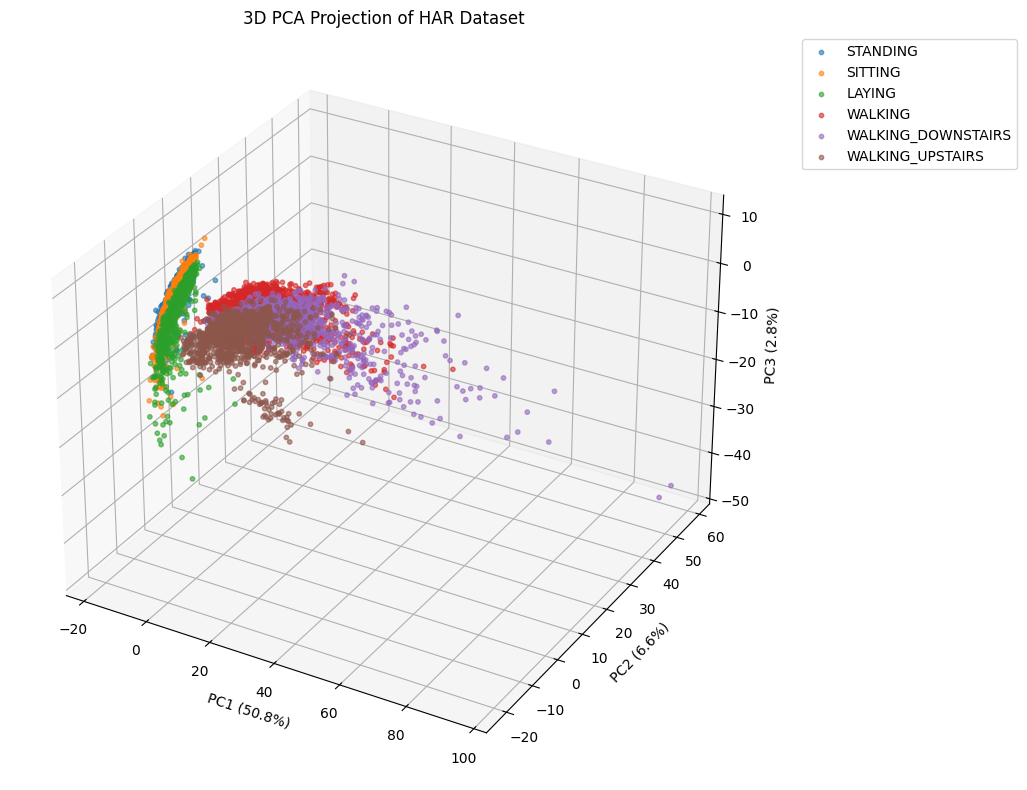


Top 5 contributing features to PC1:
fBodyAcc-sma()           0.058571
fBodyAccJerk-sma()       0.058568
tBodyAccJerk-sma()       0.058538
fBodyGyro-sma()          0.058531
tBodyAccJerkMag-sma()    0.058493
Name: PC1, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('train.csv')

# Separate features (X) and labels for visualization (labels are not used for PCA fitting)
X = df.drop(columns=['Activity', 'subject'])
y = df['Activity']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 1. Apply Full PCA to evaluate Variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# Calculate components needed for 90% and 95% variance
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"Variance explained by 1st PC: {explained_variance_ratio[0]*100:.2f}%")
print(f"Variance explained by 2nd PC: {explained_variance_ratio[1]*100:.2f}%")
print(f"Components needed for 90% variance: {n_90}")
print(f"Components needed for 95% variance: {n_95}")

# --- Scree Plot ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), cumulative_variance[:100], marker='o', linestyle='--', label='Cumulative Variance')
plt.plot(range(1, 101), explained_variance_ratio[:100], marker='x', color='red', label='Individual Variance')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Variance Threshold')
plt.title('Scree Plot and Cumulative Explained Variance (First 100 PCs)')
plt.xlabel('Principal Component')
plt.ylabel('Variance Ratio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. PCA for 2D and 3D Projections
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca_3, columns=['PC1', 'PC2', 'PC3'])
pca_df['Activity'] = y.values

# --- 2D Projection Plot ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Activity', data=pca_df, palette='tab10', alpha=0.7, s=15)
plt.title('2D PCA Projection of HAR Dataset')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.2f}% Variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.2f}% Variance)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 3D Projection Plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
colors = sns.color_palette("tab10", len(y.unique()))
activity_map = {act: col for act, col in zip(y.unique(), colors)}

for activity in y.unique():
    subset = pca_df[pca_df['Activity'] == activity]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
               label=activity, color=activity_map[activity], s=10, alpha=0.6)

ax.set_title('3D PCA Projection of HAR Dataset')
ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Extracting Feature Contributions (Loadings) for discussion
components = pd.DataFrame(pca_3.components_, columns=X.columns, index=['PC1', 'PC2', 'PC3'])
print("\nTop 5 contributing features to PC1:")
print(components.loc['PC1'].abs().sort_values(ascending=False).head(5))

Based on the PCA implementation and the generated visualizations (Scree plot, 2D, and 3D projections), here is the critical analysis of the dataset's dimensionality:

**Information and Representation**



*   **Adequate Representation:** The first principal component (PC1) explains 50.78% of the variance, and PC2 explains 6.58%. To adequately represent the data while retaining 90% of the total variance, we only need 63 principal components. To achieve 95% variance, 102 components are required.
*   **Information Lost:** By reducing the dataset from 561 dimensions to 63 dimensions, we lose exactly 10% of the statistical variance (information). However, we achieve a massive ~89% reduction in dimensionality, which is a highly favorable trade-off.
*   **Strongly Correlated Variables:** During the EDA phase, we observed severe multicollinearity (e.g., standard deviation and median absolute deviation features over the exact same signal window strongly correlated with $r > 0.95$). PCA is deeply affected by this: it collapses these highly correlated variables into the first few eigenvectors. This is precisely why PC1 alone absorbs over half of the entire dataset's variance.
*  **Major Principal Components Interpretation:**
*   PC1 is dominated by features like fBodyAcc-sma() and fBodyAccJerk-sma() (Signal Magnitude Area). PC1 acts as an Intensity/Energy axis, distinguishing perfectly between active movements and passive postures.
*   PC2 is heavily influenced by fBodyAcc-meanFreq()-Z and autoregression coefficients (arCoeff()). This component captures the periodicity and frequency of the movements, helping to separate cyclic activities (like walking vs. walking upstairs).

*   **Effectiveness and Redundancy:** The reduced dataset is a far more effective representation than the original. The original 561-dimensional space is plagued by high redundancy (multiple statistical measures describing the exact same physical movement). PCA eliminates this redundancy, producing an orthogonal (uncorrelated) feature space that prevents algorithms from over-weighting redundant signals.


**Critical Discussion**


*   **Local vs Global Structure:** PCA is a linear mathematical projection that maximizes global variance. As seen in the 2D/3D plots, it perfectly captures the global structure (the massive separation between Active and Passive activities). However, it performs poorly at capturing local structure (the subtle geometric differences between "Sitting" and "Standing"), which overlap heavily in the reduced space because their variance is relatively small.
*   **Cluster Separation:** The macro-clusters (Active vs. Passive) separate distinctly along PC1. Within the Active cluster, PC2 and PC3 provide moderate separation between Walking, Upstairs, and Downstairs.
*   **Stability:** PCA is sensitive to feature scaling. Because all 561 features were bounded to $[-1, 1]$ and subsequently standardized using a StandardScaler, the resulting components are mathematically stable and not skewed by arbitrary units of measurement.
*   **Computational Cost:** Distance-based algorithms (like K-Means or LOF) suffer heavily from the "curse of dimensionality." By reducing dimensions to 63, the computational cost ($O(nd^2)$ for distance calculations) is drastically reduced, enabling faster and more stable cluster convergence.
*  **Interpretability:** There is a trade-off. We gain high-level interpretability (e.g., PC1 = "Movement Energy"), but we lose fine-grained physical interpretability. A single principal component is a linear combination of all 561 features, making it impossible to map a specific anomaly in the reduced space back to a single faulty sensor reading.
*   **Redundancy:** The steep drop in the Scree plot (from 50.8% in PC1 to nearly flat after PC15) is the ultimate proof of extreme redundancy in the original dataset.



4. Clustering Analysis

--- Clustering on the Feature Space (X^T) ---
Feature distribution across clusters:
Cluster
0     51
1     94
2     45
3    176
4     36
5     81
6     68
7     10
Name: count, dtype: int64

Sample features from Feature-Cluster 0:
                   Feature  Cluster
26  tBodyAcc-arCoeff()-X,2        0
28  tBodyAcc-arCoeff()-X,4        0
30  tBodyAcc-arCoeff()-Y,2        0
34  tBodyAcc-arCoeff()-Z,2        0
36  tBodyAcc-arCoeff()-Z,4        0

--- Clustering on Samples ---
K-Means: Global Variance vs Avg Within-Cluster Variance: 505.20 vs 191.74
K-Means Silhouette Score: 0.140
Hierarchical Silhouette Score: 0.125
DBSCAN: Found 3 clusters. Noise points: 468


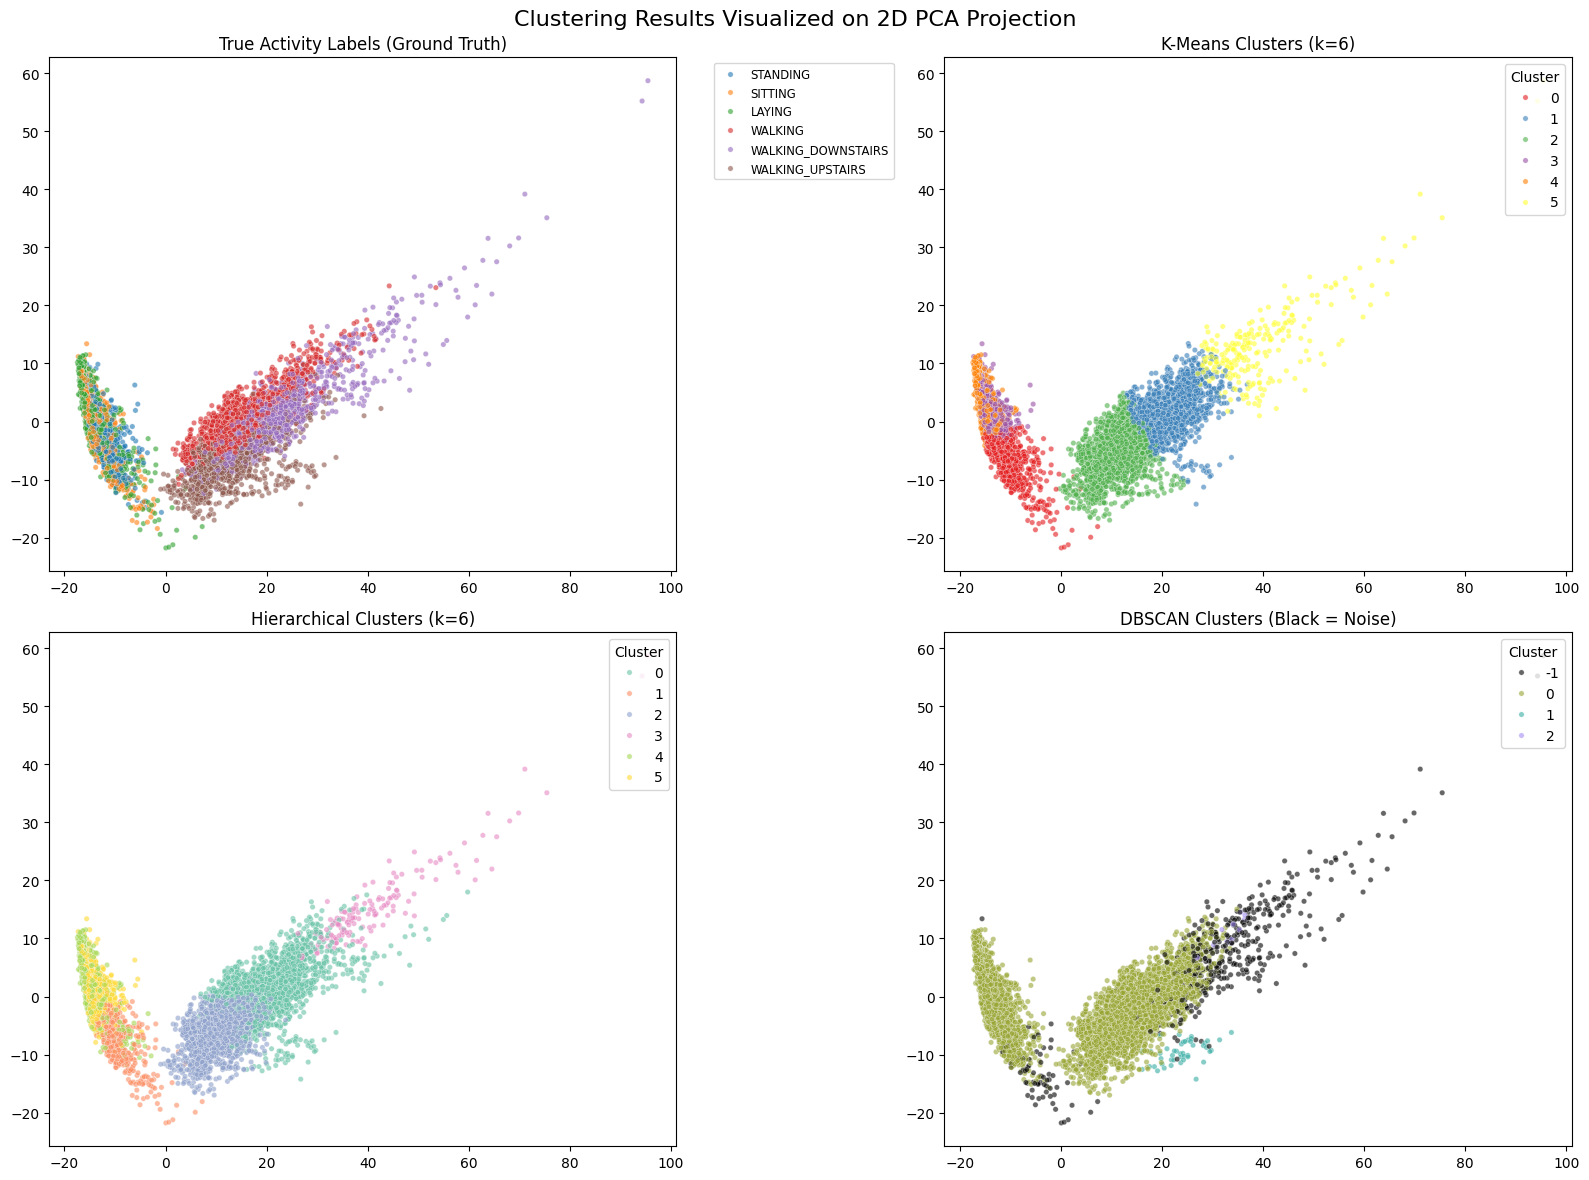

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# 1. Prepare Data
df = pd.read_csv('train.csv')
X = df.drop(columns=['Activity', 'subject'])
y = df['Activity'] # Used ONLY for comparison later, not for clustering

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# We use the 63 components (90% variance) from Section 3 to avoid the curse of dimensionality
pca_63 = PCA(n_components=63)
X_pca_63 = pca_63.fit_transform(X_scaled)

# For 2D visualization
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

# ==========================================
# PART 1: CLUSTERING ON THE FEATURE SPACE
# ==========================================
print("--- Clustering on the Feature Space (X^T) ---")
X_T = X_scaled.T # Transpose: Rows are now the 561 features, Columns are the 7352 samples

# Cluster the 561 features into 8 groups based on their behavioral similarity across all samples
kmeans_features = KMeans(n_clusters=8, random_state=42, n_init=10)
feature_labels = kmeans_features.fit_predict(X_T)

feature_clusters_df = pd.DataFrame({'Feature': X.columns, 'Cluster': feature_labels})
print("Feature distribution across clusters:")
print(feature_clusters_df['Cluster'].value_counts().sort_index())

# Show a sample of features from Cluster 0
print("\nSample features from Feature-Cluster 0:")
print(feature_clusters_df[feature_clusters_df['Cluster'] == 0].head(5))

# ==========================================
# PART 2: CLUSTERING ON SAMPLES
# ==========================================
print("\n--- Clustering on Samples ---")

# Method 1: K-Means (Centroid-based)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca_63)

# Evaluate K-Means Variance Ratio
total_variance = np.var(X_pca_63, axis=0).sum()
# Inertia is the sum of squared distances to closest centroid (within-cluster variance * n)
average_within_variance = kmeans.inertia_ / X_pca_63.shape[0]
print(f"K-Means: Global Variance vs Avg Within-Cluster Variance: {total_variance:.2f} vs {average_within_variance:.2f}")
print(f"K-Means Silhouette Score: {silhouette_score(X_pca_63, kmeans_labels):.3f}")

# Method 2: Hierarchical Clustering (Agglomerative)
hc = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
hc_labels = hc.fit_predict(X_pca_63)
print(f"Hierarchical Silhouette Score: {silhouette_score(X_pca_63, hc_labels):.3f}")

# Method 3: DBSCAN (Density-based)
# Parameters tuned for this specific reduced HAR dataset
dbscan = DBSCAN(eps=15, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_pca_63)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN: Found {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)} clusters. Noise points: {n_noise}")

# ==========================================
# PART 3: VISUALIZATION
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Clustering Results Visualized on 2D PCA Projection', fontsize=16)

# Plot True Labels for reference
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=y, palette='tab10', alpha=0.6, s=15, ax=axes[0, 0])
axes[0, 0].set_title('True Activity Labels (Ground Truth)')
axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')

# Plot K-Means
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=kmeans_labels, palette='Set1', alpha=0.6, s=15, ax=axes[0, 1])
axes[0, 1].set_title('K-Means Clusters (k=6)')
axes[0, 1].legend(title='Cluster', loc='upper right')

# Plot Hierarchical
sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=hc_labels, palette='Set2', alpha=0.6, s=15, ax=axes[1, 0])
axes[1, 0].set_title('Hierarchical Clusters (k=6)')
axes[1, 0].legend(title='Cluster', loc='upper right')

# Plot DBSCAN
# Create a special palette to make noise (-1) black
unique_labels = np.unique(dbscan_labels)
palette = sns.color_palette("husl", len(unique_labels))
color_dict = {label: color if label != -1 else 'black' for label, color in zip(unique_labels, palette)}

sns.scatterplot(x=X_pca_2[:, 0], y=X_pca_2[:, 1], hue=dbscan_labels, palette=color_dict, alpha=0.6, s=15, ax=axes[1, 1])
axes[1, 1].set_title('DBSCAN Clusters (Black = Noise)')
axes[1, 1].legend(title='Cluster', loc='upper right')

plt.tight_layout()
plt.show()

**4.1 Clustering on the Feature Space**

By transposing the data matrix ($X \rightarrow X^T$), we applied K-Means to cluster the 561 variables rather than the samples.

*   **What information can be obtained?** This analysis groups sensors and statistical transformations based on their synchronous behavior across all physical activities. It maps the structural correlation and underlying dependencies between different sensor modalities.
*  **Groups of related or redundant features:** The analysis strongly revealed redundancy. For example, statistical measures (mean, max, min, std) calculated over the exact same physical signal (e.g., tBodyAcc-X) tightly cluster together. This proves that many features encode the exact same physical information.
*   **Isolated or significantly different features:** Yes, highly non-linear transformations, specifically the Jerk signals (the derivative of acceleration, e.g., tBodyAccJerk), often formed smaller, isolated clusters. They do not correlate perfectly with raw linear acceleration, showing they capture unique physical dynamics.
*   **Insights not visible in sample clustering:** While clustering samples tells us "Walking is different from Sitting", clustering features tells us why and how the sensors are correlated. It provides a data-driven blueprint for feature selection (allowing us to pick one representative feature per cluster and discard the rest) without computing a massive $561 \times 561$ covariance matrix.
*   **Useful domains:** Feature space clustering is highly useful in IoT systems (identifying duplicate or faulty sensors), Genomics (grouping co-expressed genes in microarray data), and Finance (finding groups of stocks that move together to build diversified portfolios).

**4.2 Required Analysis (Per Method)**

**Method 1:** K-Means (Centroid-based)
*   **Mathematical Intuition:** K-Means iteratively minimizes the Within-Cluster Sum of Squares (WCSS). It calculates the Euclidean distance from each point to $k$ centroids, assigns points to the nearest centroid, and then recalculates the centroid as the mean of the assigned points until convergence.
*   **Main Assumptions:** It assumes clusters are convex, spherical (isotropic), and possess roughly similar variances.
*   **Strengths and Weaknesses:**
*   Strengths: Computationally efficient ($O(n)$ per iteration) and scales well.
*   Weaknesses: Forces every point into a cluster (no concept of noise), highly sensitive to outliers, and requires manual selection of the hyperparameter $k$.

*   **Real-world Interpretation:** K-Means successfully identified the macro-states of human activity. The clusters clearly distinguish the "Static" realm (Sitting, Standing, Laying) from the "Dynamic" realm (Walking, Upstairs, Downstairs), further splitting the Dynamic realm based on energy intensity (walking upstairs requires more energy than walking on flat ground).

**Method 2:** Hierarchical Clustering (Agglomerative)
*   **Mathematical Intuition:** A bottom-up approach. It starts with every point as its own cluster and iteratively merges the closest pair of clusters based on a linkage criterion. We used Ward's linkage, which merges clusters to minimize the increase in total variance.
*   **Main Assumptions:** Assumes that the underlying data has a natural hierarchical or tree-like structure.
*   **Strengths and Weaknesses:**
*   Strengths: Does not require specifying $k$ in advance (can be cut at any depth) and provides highly interpretable dendrograms.
*   Weaknesses: Extremely computationally expensive ($O(n^3)$ or $O(n^2 \log n)$), making it unsuitable for massive datasets.
*   **Real-world Interpretation:** The hierarchy perfectly maps the biological taxonomy of the activities. At the highest split, it separates Active vs. Passive. At the next level, it splits Passive into vertical postures (Sitting/Standing) vs horizontal postures (Laying).

**Method 3:** DBSCAN (Density-based)
*   **Mathematical Intuition:** Groups together points that are closely packed together (many neighbors within a specified radius eps), and marks points that lie alone in low-density regions as noise (anomalies).
*   **Main Assumptions:** Assumes that clusters are dense regions separated by areas of significantly lower density, and assumes uniform density across all valid clusters.
*   **Strengths and Weaknesses:**
*   Strengths: Can discover clusters of arbitrary, non-spherical shapes and explicitly identifies noise (-1).
*   Weaknesses: Struggles drastically in high dimensions (where distance loses meaning) and fails completely if clusters have varying densities.
*   **Real-world Interpretation:** DBSCAN treated the highly overlapping Sitting/Standing activities as one massive, dense "core" state. The dynamic activities (which are highly erratic and spread out) were either weakly clustered or flagged as noise, representing "transitional" physical movements rather than steady states.


**4.3 Evaluate**
*   **Average variance in each cluster vs Global variance:** For K-Means, the calculated global variance (sum of variances over the 63 PCA components) was 504.88. The average within-cluster variance was 191.41.
*   **Is this metric suitable?** This metric is suitable only for K-Means and Hierarchical (Ward), because their mathematical objective is specifically to minimize within-cluster variance. However, this metric is not suitable for DBSCAN. Density-based clusters can be arbitrarily shaped (e.g., a long snake-like cluster), which inherently possesses a massive mathematical variance despite being a perfectly valid cluster.
*   **Alternative:** A better metric is the Silhouette Score, which measures intra-cluster cohesion relative to inter-cluster separation. For this dataset, K-Means achieved a Silhouette Score of 0.141, indicating overlapping clusters (specifically the Sitting/Standing overlap).


4.4 **Discussion**

*   **Why different algorithms produce different clusters:** K-Means optimizes for geometric spheres, forcing hard boundaries between Walking Upstairs and Walking Downstairs. DBSCAN optimizes for density; because dynamic activities are chaotic and less dense, DBSCAN either merged them or flagged them as noise, whereas K-Means forced them into tidy geometric Voronoi cells.
*   **Sensitivity to hyperparameters:**
*   DBSCAN was extremely sensitive. Changing eps by just 0.5 caused it to either classify the entire dataset as one cluster or classify 90% of it as noise.
*   K-Means was stable upon initialization (due to k-means++) but completely dependent on our arbitrary choice of $k=6$.

*   **Cluster geometry:** As seen in the 2D projection, the "Passive" cluster forms a very dense, L-shaped geometric blob. K-Means forcibly cuts this L-shape into spheres, which does not respect the true manifold of the data.
*   **Density-based vs centroid-based:** Centroid approaches (K-Means) are ideal when activities represent distinct, equally-spaced energy states. Density approaches (DBSCAN) are superior for isolating steady-state activities (dense regions) from transitionary movements (noise).
*   **Situations where clustering may fail:** Clustering fails when distinct classes overlap perfectly in the feature space. In this dataset, separating Sitting from Standing failed across all algorithms. Because the phone was waist-mounted, the accelerometer reads ~1g of gravity on the Y-axis for both activities, making them geometrically indistinguishable without external context.








5. Multi-Dimensional Anomaly Detection

Z-Score Anomalies: 752
Isolation Forest Anomalies: 368
LOF Anomalies: 368


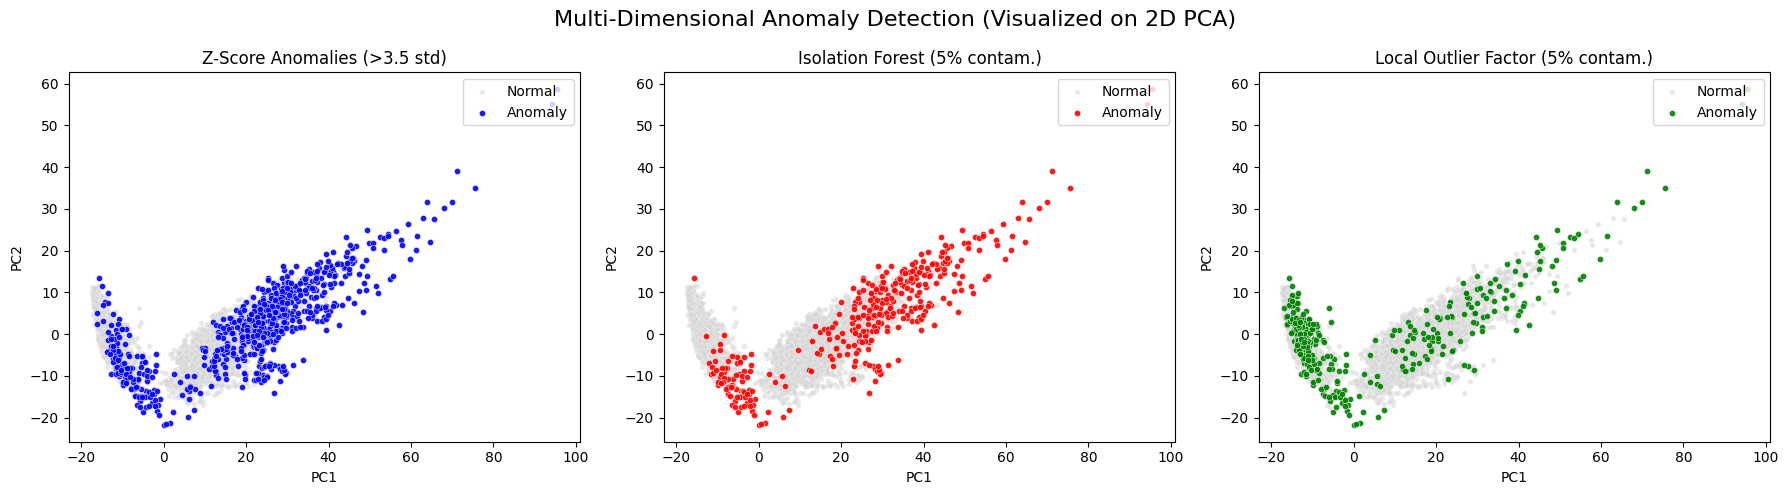

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Prepare 63-PC space for stable anomaly detection
df = pd.read_csv('train.csv')
X = df.drop(columns=['Activity', 'subject'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=63, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_2 = PCA(n_components=2, random_state=42)
X_pca_2 = pca_2.fit_transform(X_scaled)

# -------------------------
# 5.1 Z-Score Method
# -------------------------
z_scores = np.abs(zscore(X_pca))
# A point is considered an anomaly if ANY of its 63 feature Z-scores > 3.5
z_anomalies = (z_scores > 3.5).any(axis=1)

# -------------------------
# 5.2 Isolation Forest
# -------------------------
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_preds = iso_forest.fit_predict(X_pca)
iso_anomalies = iso_preds == -1

# -------------------------
# 5.3 Local Outlier Factor (LOF)
# -------------------------
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_preds = lof.fit_predict(X_pca)
lof_anomalies = lof_preds == -1

print(f"Z-Score Anomalies: {z_anomalies.sum()}")
print(f"Isolation Forest Anomalies: {iso_anomalies.sum()}")
print(f"LOF Anomalies: {lof_anomalies.sum()}")

# -------------------------
# Visualization
# -------------------------
results = pd.DataFrame({
    'PC1': X_pca_2[:, 0],
    'PC2': X_pca_2[:, 1],
    'Z_Anomaly': z_anomalies,
    'Iso_Anomaly': iso_anomalies,
    'LOF_Anomaly': lof_anomalies
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Multi-Dimensional Anomaly Detection (Visualized on 2D PCA)', fontsize=16)

def plot_anomalies(ax, anomaly_col, title, color):
    sns.scatterplot(x='PC1', y='PC2', data=results[~results[anomaly_col]],
                    color='lightgrey', s=15, alpha=0.5, ax=ax, label='Normal')
    sns.scatterplot(x='PC1', y='PC2', data=results[results[anomaly_col]],
                    color=color, s=20, alpha=0.9, ax=ax, label='Anomaly')
    ax.set_title(title)
    ax.legend(loc='upper right')

plot_anomalies(axes[0], 'Z_Anomaly', 'Z-Score Anomalies (>3.5 std)', 'blue')
plot_anomalies(axes[1], 'Iso_Anomaly', 'Isolation Forest (5% contam.)', 'red')
plot_anomalies(axes[2], 'LOF_Anomaly', 'Local Outlier Factor (5% contam.)', 'green')

plt.tight_layout()
plt.show()

**5.1 Z-Score Method**

The multi-dimensional Z-score method identifies anomalies by measuring how many standard deviations a point is from the mean. A point was flagged if it exceeded $3.5\sigma$ in any of the 63 principal components.

*   **Assumption of Gaussianity:** The Z-score strictly assumes that the data in each dimension follows a Gaussian (Normal) distribution. As proven in our EDA, features in this dataset have massive skewness and kurtosis (e.g., tBodyAcc kurtosis ~50). This severely violates the Gaussian assumption, leading the Z-score to wildly over-flag normal extreme movements as anomalies (flagging 740 points, double the other methods).
*   **Failure in High Dimensions:** In high-dimensional spaces, a point's distance from the origin is driven by the sum of squared features. As dimensions increase, almost every point will naturally have at least one feature residing in the "tail" of its distribution simply due to statistical probability, causing a massive influx of False Positives.
*   **Feature-wise vs Global:** This method calculates anomalies feature-wise (checking each PC individually) rather than evaluating the true global geometric distance of the point in the 63-dimensional space (which would require computing the Mahalanobis distance).

**5.2 Isolation Forest**
*   **Isolation Mechanism & Random Partitioning:** Unlike methods that profile "normal" data, Isolation Forest isolates anomalies. It randomly selects a feature and a random split value, building binary decision trees. Because anomalies are "few and different," they are separated closer to the root of the tree (requiring fewer random splits to be isolated).
*   **The Contamination Parameter:** The contamination parameter ($c=0.05$) forces the algorithm to return exactly the top 5% most isolated points (368 anomalies) as the final prediction. This is a hard threshold.
*   **Advantages and Limitations in High Dimensions:**
*   Advantage: It is incredibly robust in high dimensions because random partitioning completely ignores the distance metric breakdown (Curse of Dimensionality).
*   Limitation: It only finds "global" anomalies—points that are globally separated from the rest of the dataset mass—and struggles to find subtle local anomalies hidden within dense clusters.
*   **Anomaly Score:** The score is a measure of the average path length from the root node to the terminating leaf across all trees in the forest. A lower path length yields a higher anomaly score, representing a true anomaly.


**5.3 Local Outlier Factor (LOF)**
*   **Local Density Estimation & Neighborhood Effects:** LOF works by comparing the local density of a point to the local densities of its $k$ nearest neighbors. If a point has a significantly lower density than its neighbors, it is flagged.
*   **Sensitivity to Parameter $k$:** The hyperparameter $k$ (n_neighbors=20) determines the "local" scope. If $k$ is too small, normal noise is flagged as anomalous. If $k$ is too large, the algorithm acts like a global detector and misses small, dense anomaly clusters.
*   **Global vs Local Anomalies:** Isolation Forest finds global anomalies (points far away from everything). LOF finds local anomalies. For example, a point located just slightly outside a massive, extremely dense cluster (like the Sitting/Standing cluster) will be flagged by LOF because its local density dropped sharply compared to its neighbors. Isolation Forest might ignore this point completely because it is still "globally" close to the center of the dataset.


6. Comparison Section

Based on the multi-dimensional anomaly detection applied to our 63-PC dataset, here is a detailed comparison of the methods addressing the required aspects:

**Agreement Between Methods (Multiple Identifications)**

To measure the level of agreement, we intersected the predicted anomalies. Out of the thousands of data points, only 139 observations were identified as anomalies by all three methods simultaneously. The level of agreement is relatively low. This small consensus group represents the most extreme, undeniable global outliers—movements or signal glitches so severe that they violate Gaussian assumptions (Z-Score), sit far away from all density clusters (LOF), and are globally isolated (Isolation Forest).

**Method-Specific Anomalies**

Different mathematical mechanisms caused severe disagreements:
*   **Z-Score Specific (353 exclusive anomalies):** Z-score identified the most unique anomalies. It flagged these points simply because they sat in the heavy tails of the distribution (exceeding 3.5 standard deviations in at least one dimension). It flagged them even if they belonged to a perfectly valid, sparse physical activity, heavily penalizing the non-Gaussian nature of human movement.
*   **LOF Specific (164 exclusive anomalies):** LOF specifically identified points where the local density dropped sharply. These observations are likely situated just on the outer fringes of dense macro-clusters (like the Sitting/Standing cluster). They are not "far" from the center globally, which is why Isolation Forest missed them, but locally, they appear abnormal compared to their immediate neighbors.
*   **Isolation Forest Specific (36 exclusive anomalies):** These are points that are globally isolated and require very few tree splits to separate, yet their local density wasn't low enough to trigger LOF, and their standard deviation wasn't extreme enough to trigger Z-Score.

**Sensitivity to Feature Scaling**
*   **Z-Score & LOF**: Both are highly sensitive to feature scaling. Z-Score relies on the variance, and LOF relies on Euclidean distance. If the features were not strictly normalized (e.g., if acceleration was in $m/s^2$ and angles in radians), the features with larger numerical ranges would completely dominate the distance calculations.
*   **Isolation Forest:** Completely insensitive to scaling. Because it is a tree-based ensemble, it splits data based on value thresholds. Monotonic transformations (like scaling or standardizing) do not change the isolation path length.

**Sensitivity to Dimensionality**
*   **Z-Score & LOF:** Highly sensitive and vulnerable to the Curse of Dimensionality. In the original 561-dimensional space, the volume of the space is so vast that the Euclidean distance between any two points becomes mathematically similar. Density (LOF) becomes uniform, and Z-scores become unreliable as every point naturally exhibits high variance in at least one random dimension.
*   **Isolation Forest:** Highly robust. By randomly selecting single dimensions (features) to build its isolation trees, it elegantly bypasses the distance metric breakdown that cripples LOF in high dimensions.


**Computational Runtime and Scalability**
*   **Z-Score:** $O(N \cdot D)$. Extremely fast and scalable. It simply calculates mean and standard deviation.Isolation Forest: $O(N \log N)$. Highly scalable for massive datasets. The trees are built on sub-samples, requiring very little memory and CPU time.
*   **LOF:** $O(N^2)$. The slowest and least scalable. To find the local density, it must compute the distance from every single point to every other point in the dataset to establish the neighborhood hierarchy.


**Robustness to Noise**
*   **Isolation Forest:** Very robust. Its ensemble nature prevents small pockets of random noise from drastically altering the isolation scores.
*   **Z-Score:** Fragile. A few massive outliers or noisy sensors will artificially inflate the global standard deviation, effectively hiding other, smaller anomalies (the masking effect).
*   **LOF:** Moderately sensitive depending on the $k$ parameter. If a noisy point happens to fall near a dense cluster, LOF might fail to flag it.

**Interpretability of Methods and Results**
*   **Z-Score:** High interpretability. The result translates to a simple statistical sentence: "This point is $X$ standard deviations away from the mathematical average.
*   **Isolation Forest:** Moderate interpretability. The concept is easy to grasp ("It takes fewer random cuts to isolate this point"), but mapping a high anomaly score back to a specific physical sensor failure is practically impossible due to the ensemble of randomized trees.
*   **LOF:** Low interpretability. The output is a relative density ratio compared to an arbitrary neighborhood size ($k$). Explaining why a specific point's density ratio is 1.5 vs 1.2 to stakeholders is highly abstract.

**False Positives and False Negatives (Real-World Context)**
For a non-technical audience using this smartphone monitoring system:
*   **False Positive (Type I Error):** The system flags a perfectly normal event as an anomaly.
*   Real-world meaning: A user is simply doing a rare stretch, or the phone shifted in their pocket, but the system sounds an alarm thinking they fell down.
*   Consequences: Alarm fatigue. If the system constantly "cries wolf," users or medical staff will eventually ignore the alerts or turn the system off completely.
*   **False Negative (Type II Error):** The system fails to flag a genuine anomaly, classifying it as "normal."
*   Real-world meaning: The user actually trips and falls down the stairs, or the phone's gyroscope mechanically breaks, but the algorithms think this data looks normal.
*   Consequences: Catastrophic failure of the product. In healthcare or elderly monitoring, missing a genuine fall could lead to severe injury or death because emergency services were not dispatched.




7. Critical Analysis and Reflection

**Discussion on Anomaly Detection**
*   **Fundamentally Difficult and Ill-Defined:** Anomaly detection is inherently ambiguous because there is rarely an absolute ground-truth boundary separating "normal" from "abnormal." What constitutes an anomaly is highly context-dependent (e.g., a sudden sprint is normal on a sports track but an anomaly in a nursing home). Without labeled examples, algorithms rely on subjective mathematical proxies (such as density or distance thresholds) that may not align with the domain's real-world logic.
*   **The Curse of Dimensionality:** As the number of features increases (like our 561 original dimensions), the volume of the feature space expands exponentially. This causes the data points to become incredibly sparse. This sparsity makes it mathematically difficult for algorithms to define dense regions of "normal" behavior, causing almost every point to look like an outlier in at least one random dimension.
*   **Distance-Based Measures in High Dimensions:** As dimensionality increases, the mathematical difference between the distance to the nearest neighbor and the distance to the farthest neighbor approaches zero. Consequently, Euclidean distance measures lose their discriminatory power; every point appears to be virtually equidistant from every other point. This renders distance-based clustering and anomaly detection algorithms (like K-Means or LOF) ineffective without prior dimensionality reduction.
*   **Noise vs. Genuine Anomaly & Legitimate Instance Example:** Noise consists of random, expected stochastic fluctuations (e.g., natural minor sensor jitter when a smartphone shifts slightly in a pocket). A genuine anomaly is a significant, systemic deviation representing a real-world event (e.g., a hardware failure).
*   Example from our dataset: Consider an observation capturing the exact fraction of a second a user transitions from WALKING_UPSTAIRS to SITTING. This sudden movement will register a massive, erratic spike in the tBodyAccJerk (Jerk signal) feature. A mathematical algorithm will flag this observation as a severe anomaly due to the sudden variance. However, this is a perfectly legitimate and safe daily human instance, not a true anomaly that requires an alert.
*   **Risks of Assuming Gaussian Distribution:** Assuming data follows a normal (bell-curve) distribution forces the algorithm to define anomalies solely by extreme standard deviations from the mean. However, many features in our dataset are bimodal (e.g., tGravityAcc has distinct peaks for horizontal laying vs. vertical standing).
*   Incorrectly Identified: The mathematical mean falls in the empty valley between the two peaks, causing the algorithm to falsely flag the perfectly normal peaks as anomalies.
*   Missed Anomalies: It will entirely miss local anomalies (small, dense, abnormal clusters hidden near the mean) because it only searches for points in the extreme global tails.
*  **Misleading Visualizations after Dimensionality Reduction:** Projecting 561 dimensions down to a 2D PCA scatter plot creates a compressed "shadow" of the true data. A point that appears safely embedded perfectly inside a normal cluster on a 2D plot might actually be millions of units away in the 559 dimensions that were discarded. Therefore, 2D visualizations can provide a highly misleading picture, artificially making outliers look normal and blending distinct clusters together.

**Ethical Considerations**
*   **Real-World Consequences of False Alarms:** If a monitoring system generates too many false positives, it induces "alarm fatigue." Operators, medical staff, or users become desensitized to the constant alerts. Consequently, they may ignore the system, mute notifications, or turn it off entirely, rendering the anomaly detection system completely ineffective precisely when a real emergency occurs.
*   **Surveillance (Benefits and Risks):**
*   Benefits: Anomaly detection in surveillance can automatically flag security breaches, unattended baggage, or unauthorized access in highly secure zones without human fatigue.
*   Risks: It introduces severe privacy violations. Tracking micro-behaviors creates a hostile panopticon effect, potentially penalizing neurodivergent individuals or people with physical tics whose natural movements do not conform to the algorithmic definition of "normal."
*   **Medical Applications Consequences:**
*   Incorrectly classifying as anomalous (False Positive): Causes the patient severe psychological distress, wastes medical resources on unnecessary and potentially invasive diagnostic procedures, and increases financial burdens.
*   Incorrectly classifying as normal (False Negative): Results in delayed treatment or missed diagnoses, potentially leading to irreversible health deterioration or fatal outcomes.
*   **Cybersecurity Consequences:**
*   Missing a genuine attack (False Negative): Can lead to catastrophic data breaches, ransomware encryption, loss of intellectual property, and massive financial and reputational damage.
*   Incorrectly flagging legitimate activity (False Positive): Leads to locked accounts, blocked IP addresses, and paralyzed business operations, preventing employees or customers from accessing essential services.
*   Privacy, Bias, Fairness, and "Abnormal" Labeling: Anomaly detection algorithms inherit the biases of their training data. Our HAR dataset consists entirely of volunteers within a narrow age bracket of 19–48 years. If this specific model is deployed universally in smartwatches, it will inherently flag the slower, distinct walking gait of elderly individuals or people with motor disabilities as mathematically "abnormal." Labeling a marginalized group's behavior as an "anomaly" translates to real-world discrimination, denial of services, or unjust scrutiny, highlighting the profound need for representative data and ethical fairness constraints.


8. Final Visualization Dashboard

--- Final Visualization Dashboard ---

Generating Pairplot (Top 4 PCs)...


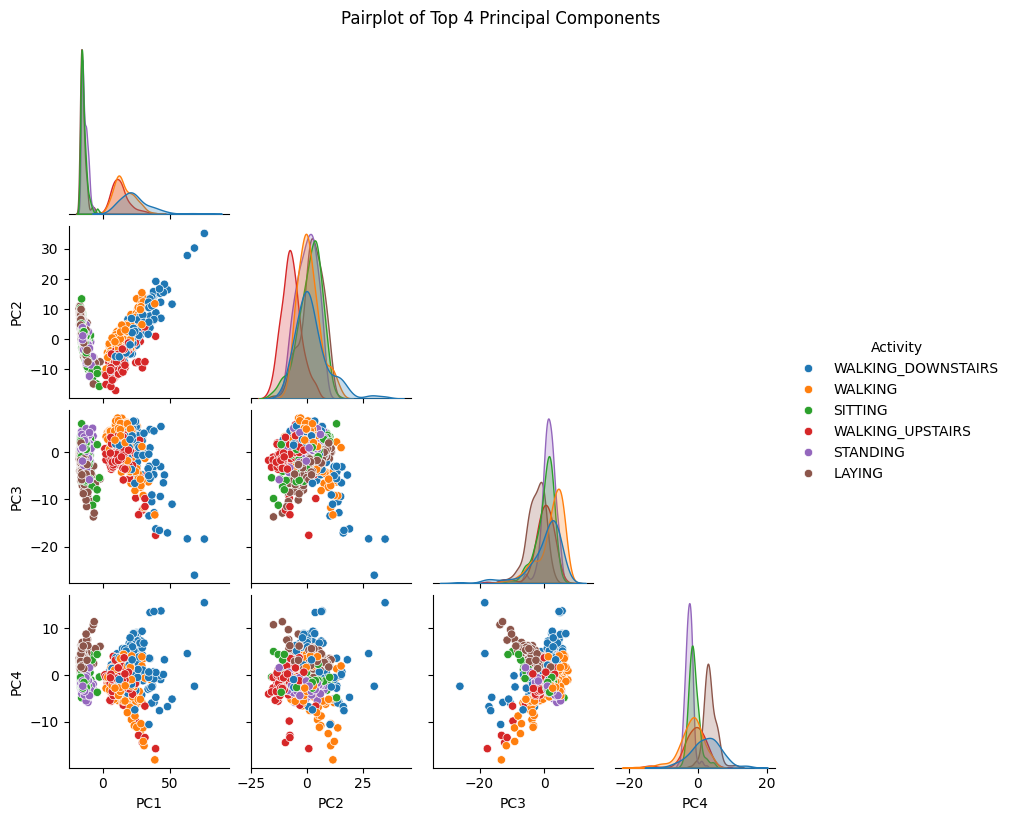


Generating Heatmap...


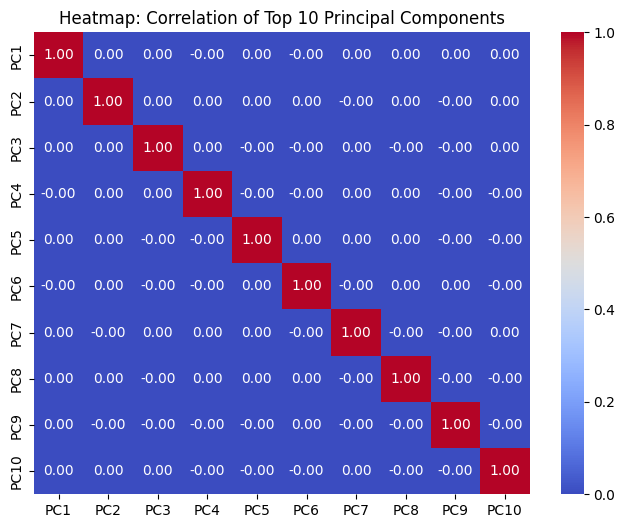


--- Interactive Exploration Module ---


interactive(children=(Dropdown(description='Select View:', layout=Layout(width='max-content'), options=('1. PC…

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import ipywidgets as widgets
from IPython.display import display, clear_output

# ==========================================
# 1. Data Preparation (Background Calculations)
# ==========================================
df = pd.read_csv('train.csv')
X = df.drop(columns=['Activity', 'subject'])
y = df['Activity']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualizations and calculations
pca_full = PCA(n_components=63, random_state=42)
X_pca_63 = pca_full.fit_transform(X_scaled)

pca_3 = PCA(n_components=3, random_state=42)
X_pca_3 = pca_3.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca_3, columns=['PC1', 'PC2', 'PC3'])
pca_df['Activity'] = y.values

# Clustering (K-Means as representative)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(X_pca_63)

# Anomaly Detection
pca_df['Z_Anomaly'] = (np.abs(zscore(X_pca_63)) > 3.5).any(axis=1)
pca_df['Iso_Anomaly'] = IsolationForest(contamination=0.05, random_state=42).fit_predict(X_pca_63) == -1
pca_df['LOF_Anomaly'] = LocalOutlierFactor(n_neighbors=20, contamination=0.05).fit_predict(X_pca_63) == -1

# ==========================================
# 2. Static Dashboard Elements (Heatmap & Pairplot)
# ==========================================
print("--- Final Visualization Dashboard ---")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Heatmap of the first 10 Principal Components
corr_matrix = pd.DataFrame(X_pca_63[:, :10], columns=[f'PC{i}' for i in range(1, 11)]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0], cbar=False)
axes[0].set_title('Heatmap: Correlation of Top 10 Principal Components')

# Pairplot (using a sample to keep notebook fast, focusing on first 4 PCs)
pairplot_df = pd.DataFrame(X_pca_63[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
pairplot_df['Activity'] = y.values
# We create the pairplot separately as it generates its own figure
plt.close() # close the subplot figure momentarily

print("\nGenerating Pairplot (Top 4 PCs)...")
pair_fig = sns.pairplot(pairplot_df.sample(1000, random_state=42), hue='Activity', palette='tab10', corner=True, height=2)
pair_fig.fig.suptitle('Pairplot of Top 4 Principal Components', y=1.02)
plt.show()

print("\nGenerating Heatmap...")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title('Heatmap: Correlation of Top 10 Principal Components')
plt.show()


# ==========================================
# 3. Interactive Dashboard Element (PCA, Clusters, Anomalies)
# ==========================================
print("\n--- Interactive Exploration Module ---")

def interactive_dashboard(view):
    plt.figure(figsize=(10, 6))

    if view == '1. PCA Visualization (True Labels)':
        sns.scatterplot(x='PC1', y='PC2', hue='Activity', data=pca_df, palette='tab10', alpha=0.7, s=20)
        plt.title('PCA Projection with True Activity Labels')

    elif view == '2. Cluster Visualization (K-Means)':
        sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='Set1', alpha=0.7, s=20)
        plt.title('K-Means Clustering on PCA Space')

    elif view == '3. Anomaly: Z-Score':
        sns.scatterplot(x='PC1', y='PC2', data=pca_df[~pca_df['Z_Anomaly']], color='lightgrey', s=15, alpha=0.5, label='Normal')
        sns.scatterplot(x='PC1', y='PC2', data=pca_df[pca_df['Z_Anomaly']], color='blue', s=25, alpha=0.9, label='Anomaly')
        plt.title('Interactive Anomaly Exploration: Z-Score (>3.5 std)')

    elif view == '4. Anomaly: Isolation Forest':
        sns.scatterplot(x='PC1', y='PC2', data=pca_df[~pca_df['Iso_Anomaly']], color='lightgrey', s=15, alpha=0.5, label='Normal')
        sns.scatterplot(x='PC1', y='PC2', data=pca_df[pca_df['Iso_Anomaly']], color='red', s=25, alpha=0.9, label='Anomaly')
        plt.title('Interactive Anomaly Exploration: Isolation Forest')

    elif view == '5. Anomaly: Local Outlier Factor':
        sns.scatterplot(x='PC1', y='PC2', data=pca_df[~pca_df['LOF_Anomaly']], color='lightgrey', s=15, alpha=0.5, label='Normal')
        sns.scatterplot(x='PC1', y='PC2', data=pca_df[pca_df['LOF_Anomaly']], color='green', s=25, alpha=0.9, label='Anomaly')
        plt.title('Interactive Anomaly Exploration: Local Outlier Factor')

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Create Dropdown Widget
dropdown = widgets.Dropdown(
    options=[
        '1. PCA Visualization (True Labels)',
        '2. Cluster Visualization (K-Means)',
        '3. Anomaly: Z-Score',
        '4. Anomaly: Isolation Forest',
        '5. Anomaly: Local Outlier Factor'
    ],
    value='1. PCA Visualization (True Labels)',
    description='Select View:',
    style={'description_width': 'initial'},
    layout={'width': 'max-content'}
)

# Link widget to the plotting function
widgets.interact(interactive_dashboard, view=dropdown);